
Preliminar, notemos el problema

![z_score_modificado](../imagenes/z_score_mod_2.png)

Es importante ver que al usar el método de Z-score modificado para variables univariadas, solo un grupo de datos con esa perspectivas se identifican como atípicos. Sin embargo, el análisis univariado se queda corto cuando mis datos tiene una naturaleza multivariada. Por ejemplo, los puntos verdes, es claro que son atípicos pero el método univariado no es capaz de identificadorlos ¿Qué hacer?. 


--------------------------------------------------------------------------------

Para el problema anterior están los métodos multivariados. 

## Método de Distancia de Mahalanobis
Es un métodos parecido al z-score pero en más dimensiones, pues, recordemos la distancia de Mahalanobis es directamente la estandarización multivariada

Mientras el z-score o el modificado evalúa la distancia de una variable a su media en una sola dimensión, la Distancia de Mahalanobis (MD) evalúa que tan lejos está un punto del centro de gravedad de la nube de puntos (centroide). 

(No se puede hacer z-score en cada variable y simplmeente buscar los datos que estén más grandes que el 3 en cada variable porque en ese caso se estaría asumiendo que las variables generan un hipercubo y que los datos atípicos estarían afuera de este, pero, como normalmente hay una correlación entre variables esto no pasa.)

Mahalanobis deforma el espacio basándose en la correlación y crea una elipse en 2D o un elipsoide 3D. 

* Los puntos que caen sobre la misma línea elíptica tienen exactamente la misma distancia de Mahalanobis al centroide(distancia de medias). 

* Al multipliclar por  la inversa de la matriz de covarianza, Mahalanobis comprime el eje donde los datos varían mucho y estira el eje donde varían poco

$$D_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$

$$D_M^2 = (x - \mu)^T \Sigma^{-1} (x - \mu)$$

$D_M^2$ tiene una distribución $\chi^2_p$ siendo p- el número de variables. Además, $D_M^2$ tranforma una nube de puntos elíptica y correlacionada en una esfera. La distancia desde el centro a cualquier punto es una suma de puntuaciones Z estándar al cuadrado. 

Cuando se calcula la distancia de Mahalanobis al cuadrado para un punto en un espacio de p-dimensiones, lo que se hace es rotar el espacio y calcular: 

$$D_M^2 = \frac{y_1^2}{\lambda_1} + \frac{y_2^2}{\lambda_2} + \dots + \frac{y_p^2}{\lambda_p}$$

que es una distancia al cudrado dividida por su varianza, es decir, una v.a normal al cuadrado. (el Y es una tranasformación que viene de la desomposición espectral de $\Sigma^{-1}$) Por tanto, si los datos originales siguen una distribución normal multivariante, la distancia $D_M^2$ sigue una distribución chi-cudrado con p-grados de libertad. 

Para usarla como filtro de outliers se plantea una prueba de hipótesis: 

$$H_0: \text{El dato pertenece a la distribución normal multivariante de la población}$$
$$H_1: \text{El dato está demasiado lejos del centroide para ser una fluctuación aleatoria común}$$

Se suele usar un $\alpha = 0.001$, si, una confianza del 99.9% para detectar los datos atípicos. 

Entonces por ejemplo, si se tien p = 3 variables, entonces $\chi^2_{0.001,3} = 16.27$ de tal manera que en este caso de tres variables un distancia de Mahalanobis mayor a 16.27 se considera dato atípico.

$$ D_M^2 > \chi^2_{critico} \rightarrow \text{es un outlier}$$

(o pues también se usa el valor-p)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from matplotlib.patches import Ellipse

# 1. FIJAR SEMILLA PARA REPRODUCIBILIDAD
np.random.seed(42)

# 2. GENERAR DATOS REALISTAS SIMULADOS (Normal Multivariante)
# Imaginemos dos variables altamente correlacionadas: "Estatura" e "Ingresos"
n_samples = 300

#Vector de medias (centroide)
mu = np.array([170, 2500])  # Medias: 170 cm, $2500

# Matriz de covarianza (indica alta correlación positiva)
covariance_matrix = np.array([
    [100, 3500],  
    [3500, 250000]
])

# Generamos la nube de puntos normal
X = np.random.multivariate_normal(mu, covariance_matrix, n_samples)
X


#Note que los datos simulados son de una variable aleatoria normal multivariada
#la cual es simétrica, por tanto, es posible usar el método de la
#distnacia de Mahalanobis. 

array([[ 172.49049726, 2748.37089531],
       [ 185.40922125, 2823.69198884],
       [ 166.68884748, 2382.94672418],
       [ 186.5362505 , 3289.52966324],
       [ 170.58690315, 2265.20856614],
       [ 163.43009071, 2268.33772226],
       [ 158.03320581, 2621.17242464],
       [ 153.9083632 , 1637.59731894],
       [ 165.15247089, 1993.55303126],
       [ 153.55864617, 2046.12917456],
       [ 178.64958491, 3232.8469431 ],
       [ 160.30005112, 2533.90654912],
       [ 166.98053408, 2227.79755305],
       [ 164.62389607, 1924.46566021],
       [ 163.71196983, 2199.70982482],
       [ 179.01251368, 2198.96150766],
       [ 162.35341392, 2493.35713854],
       [ 167.04213035, 2911.39450874],
       [ 157.47024275, 2604.62772479],
       [ 162.10639602, 1835.88730649],
       [ 176.39389492, 2869.21614908],
       [ 167.04040791, 2442.20596455],
       [ 154.50852673, 1760.81099019],
       [ 174.32275375, 2269.57492721],
       [ 159.81766162, 2671.9854115 ],
       [ 169.51955206, 26

<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1057/282665855.py:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.scatter(mu[0], mu[1], color='red', marker='x', s=150, linewidths=3, label='Centroide ($\mu$)')


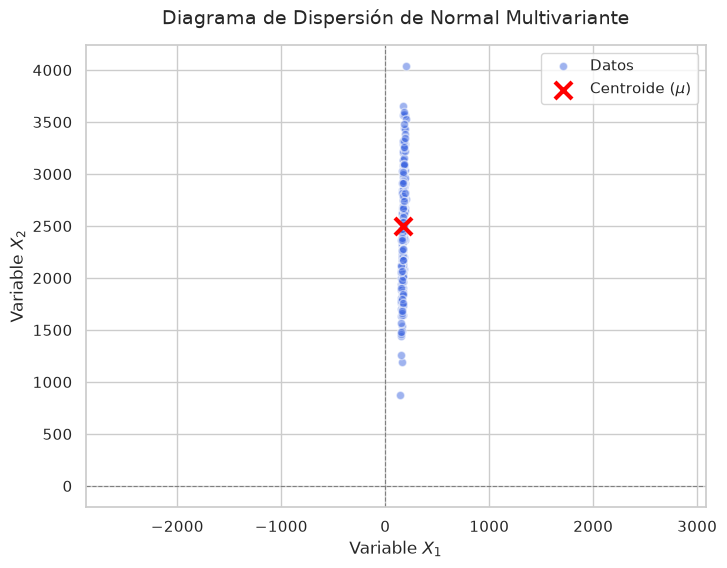

In [16]:
# 2. Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 3. Graficar los puntos
# X[:, 0] toma la primera variable, X[:, 1] toma la segunda variable
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, edgecolors='w', color='royalblue', label='Datos')

# 4. Graficar el centroide (el vector de medias)
plt.scatter(mu[0], mu[1], color='red', marker='x', s=150, linewidths=3, label='Centroide ($\mu$)')

# 5. Personalizar el gráfico
plt.title('Diagrama de Dispersión de Normal Multivariante', fontsize=14, pad=15)
plt.xlabel('Variable $X_1$', fontsize=12)
plt.ylabel('Variable $X_2$', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(fontsize=11)
plt.axis('equal') # Mantiene la misma escala en ambos ejes para no distorsionar la covarianza

# Mostrar el resultado
plt.show()

In [17]:
type(X)
X.shape #es un atributo

(300, 2)

In [ ]:
# 3. INYECTAR OUTLIERS MULTIVARIANTES (El "Sujeto de 1.95m y $500")
# Estos puntos individualmente parecen normales, pero rompen la correlación
outliers = np.array([
    [195, 600],   # Muy alto pero gana muy poco
    [150, 4500],  # Muy bajo pero gana muchísimo
    [172, 2600]   # Un dato perfectamente normal para contrastar
])

#vstack es par concatenar arreglos, solo se le une los datos 
#atípicos
X = np.vstack([X, outliers])
X_centered = X - mu
Sigma_inv = np.linalg.inv(covariance_matrix)


La Distancia de Mahalanobis al cuadrado ($D_M^2$): Es una métrica de distancia. No te devuelve las variables transformadas, sino que comprime tus 2 variables en un único número por cada fila. Es un indicador que te dice: "Este dato está a una distancia de 1.5 del centro de la nube". Que és la ubicación de un punto en varias dimensiones a la vez.

Notese que si se hace esta operación orignalmente con la fórmula de multiplicación de matrices, para muchos datos esto puede ser muy pesado para la ram. En este caso, se tendría una matriz 303x303. Para evitar el desperdicio de memoria, el código hace algo brillante. 

Es decir, las distancias reales que a ti te interesan quedan exactamente en la diagonal principal de esa matriz gigante. Todas las demás celdas fuera de la diagonal (las posiciones $(0,1)$, $(5,12)$, etc.) son basura que miden relaciones cruzadas entre registros diferentes que no nos sirven para nada.

Paso 1: El Producto Punto Inicial (np.dot)Multiplica tus datos por la inversa de la covarianza.Matriz_A = np.dot(X_centered, Sigma_inv)Esto nos da una matriz de $302 \times 2$. Hasta aquí, todo normal.

Paso 2: El "Espejo" con el asterisco (*)En lugar de transponer toda la matriz original y hacer una multiplicación de matrices (que crearía el monstruo de $302 \times 302$), el código usa el asterisco *.Recuerda que el asterisco multiplica celda por celda en la misma posición. Lo que hace NumPy es tomar la fila 1 de Matriz_A y multiplicarla elemento por elemento por la fila 1 de X_centered. Luego la fila 2 con la fila 2...

Matemáticamente, hacer esta multiplicación manual elemento por elemento equivale exactamente a hacer el producto punto de esa fila individual por su propia transpuesta. Lograste el mismo efecto, pero manteniendo tus datos en una cómoda matriz de $302 \times 2$.

Paso 3: El toque final (np.sum(..., axis=1))
En la fórmula matemática original, el paso final te da un solo número. En nuestro resultado temporal del paso anterior, tenemos los dos pedazos separados: [A*X, B*Y].

¿Qué falta para tener la distancia final de esa fila? Sumarlos.

Al aplicar np.sum(..., axis=1), NumPy suma de forma horizontal (A*X) + (B*Y) para cada una de las 302 filas.

In [20]:
#La idead es calcular DM^2 que es (x - mu)^t sigma2 (x - mu) pero puede ser pesado para la ram.
#entonces esta es una forma más óptima.

#print(np.dot(X_centered, Sigma_inv))
#print(np.dot(X_centered, Sigma_inv)*X_centered)
print(np.sum(np.dot(X_centered, Sigma_inv) * X_centered, axis=1))

[2.65841967e-01 2.73912039e+00 1.09647918e-01 3.08286918e+00
 5.14777600e-01 4.31660161e-01 3.71918704e+00 3.29150879e+00
 1.12457826e+00 2.81910947e+00 2.19910125e+00 2.03446745e+00
 3.08656372e-01 1.46593522e+00 4.45852079e-01 3.79298532e+00
 1.11893458e+00 2.16703935e+00 3.88393100e+00 1.80283253e+00
 5.74699978e-01 1.04037961e-01 2.70420296e+00 1.32969548e+00
 3.22638412e+00 2.53318782e-01 8.32371277e-01 1.93024268e+00
 7.99898345e-01 1.06142376e+00 2.64077206e-01 2.65488736e+00
 2.49958523e+00 1.01226373e+00 5.46960112e-01 2.49616326e+00
 2.44939327e+00 7.53858814e+00 9.69825877e-02 3.95885023e+00
 1.75785127e-01 2.45277483e+00 9.05422037e-01 9.46038329e-01
 5.44089331e-01 9.47697168e-01 6.00241029e-01 2.29562481e+00
 1.55837074e-01 5.50572706e-02 2.18021683e+00 7.61102057e-01
 1.89270176e-01 3.58817467e+00 7.18743981e-02 3.68238596e+00
 6.07118938e+00 1.27933540e-01 1.36701326e+00 1.87144727e+00
 1.45271708e+00 3.93301828e+00 5.14249710e+00 1.30185533e+00
 2.63418129e-01 2.409257

<>:75: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:75: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_1057/764927621.py:75: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title('Detección Multivariante de Outliers mediante Mahalanobis y $\chi^2$', fontsize=14)


Longitud de vector X al unir los 3 vectores(309, 2)

[[ 1.96078431e-02 -2.74509804e-04]
 [-2.74509804e-04  7.84313725e-06]]

[[ 2.49049726e+00  2.48370895e+02]
 [ 1.54092212e+01  3.23691989e+02]
 [-3.31115252e+00 -1.17053276e+02]
 [ 1.65362505e+01  7.89529663e+02]
 [ 5.86903153e-01 -2.34791434e+02]
 [-6.56990929e+00 -2.31662278e+02]
 [-1.19667942e+01  1.21172425e+02]
 [-1.60916368e+01 -8.62402681e+02]
 [-4.84752911e+00 -5.06446969e+02]
 [-1.64413538e+01 -4.53870825e+02]
 [ 8.64958491e+00  7.32846943e+02]
 [-9.69994888e+00  3.39065491e+01]
 [-3.01946592e+00 -2.72202447e+02]
 [-5.37610393e+00 -5.75534340e+02]
 [-6.28803017e+00 -3.00290175e+02]
 [ 9.01251368e+00 -3.01038492e+02]
 [-7.64658608e+00 -6.64286146e+00]
 [-2.95786965e+00  4.11394509e+02]
 [-1.25297572e+01  1.04627725e+02]
 [-7.89360398e+00 -6.64112694e+02]
 [ 6.39389492e+00  3.69216149e+02]
 [-2.95959209e+00 -5.77940355e+01]
 [-1.54914733e+01 -7.39189010e+02]
 [ 4.32275375e+00 -2.30425073e+02]
 [-1.01823384e+01  1.71985412e+02]


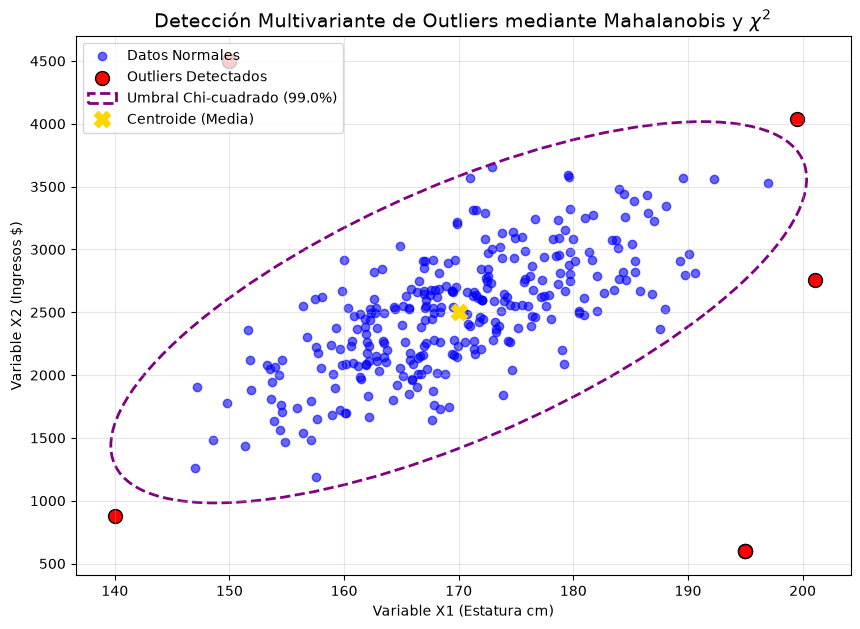


--- Análisis de los puntos de prueba ---
Punto Normal de Control:
  Coordenadas: [ 172. 2600.]
  Distancia Mahalanobis al cuadrado ($D_M^2$): 0.05
  ¿Es clasificado como outlier?: False
Outlier 2 (Bajo/Alto ingreso):
  Coordenadas: [ 150. 4500.]
  Distancia Mahalanobis al cuadrado ($D_M^2$): 61.18
  ¿Es clasificado como outlier?: True
Outlier 1 (Alto/Bajo ingreso):
  Coordenadas: [195. 600.]
  Distancia Mahalanobis al cuadrado ($D_M^2$): 66.65
  ¿Es clasificado como outlier?: True


In [ ]:

print(f"Longitud de vector X al unir los 3 vectores{X.shape}")

print()
print(Sigma_inv)
print()
print(X_centered)
print()

# Aplicamos la fórmula matemática: D_M^2 = z^T * Sigma^-1 * z directamente 
#a los datos

# Lo hacemos de forma matricial eficiente para todos los registros
dm_squared = np.sum(np.dot(X_centered, Sigma_inv) * X_centered, axis=1) 

# 5. FILTRADO POR DISTRIBUCIÓN CHI-CUADRADO
p_dimensions = 2
alpha = 0.01  # Nivel de significancia del 1%
#confianza del 99% 

# Encontrar el valor crítico teórico de Chi-cuadrado
#cuantil chi-cudrado que deja a la izquierda una probadilidad
#del 99% con 2 gradso de libertad
chi2_critical = chi2.ppf(1 - alpha, df=p_dimensions)
print(f"Valor crítico de Chi-cuadrado (gl={p_dimensions}, alpha={alpha}): {chi2_critical:.2f}")

# Identificar cuáles registros superan el umbral
is_outlier = dm_squared > chi2_critical

# 6. VISUALIZACIÓN GEOMÉTRICA
fig, ax = plt.subplots(figsize=(10, 7))

# Graficar datos normales y outliers detectados
ax.scatter(X[~is_outlier, 0], X[~is_outlier, 1], c='blue', alpha=0.6, label='Datos Normales')
ax.scatter(X[is_outlier, 0], X[is_outlier, 1], c='red', edgecolors='black', s=100, label='Outliers Detectados')

# Dibujar la Elipse de Mahalanobis correspondiente al umbral Chi-cuadrado
# Para dibujar la elipse de corte de forma exacta, usamos la descomposición espectral
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
order = eigenvalues.argsort()[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

# El ángulo de rotación de la elipse
angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

# El ancho y alto de la elipse escalados por el valor crítico de Chi-cuadrado
width, height = 2 * np.sqrt(chi2_critical * eigenvalues)

# Construir el parche de la elipse
ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle,
                  edgecolor='purple', fc='none', lw=2, ls='--', label=f'Umbral Chi-cuadrado ({1-alpha:.1%})')
ax.add_patch(ellipse)

# Graficar el centroide (Media)
ax.plot(mu[0], mu[1], 'X', color='gold', markersize=12, label='Centroide (Media)')

# Detalles estéticos del gráfico
ax.set_title('Detección Multivariante de Outliers mediante Mahalanobis y $\chi^2$', fontsize=14)
ax.set_xlabel('Variable X1 (Estatura cm)')
ax.set_ylabel('Variable X2 (Ingresos $)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.show()

# Mostrar resultados numéricos de los últimos 3 puntos que inyectamos
print("\n--- Análisis de los puntos de prueba ---")
nombres_prueba = ["Outlier 1 (Alto/Bajo ingreso)", "Outlier 2 (Bajo/Alto ingreso)", "Punto Normal de Control"]
for i in range(1, 4):
    idx = -i
    print(f"{nombres_prueba[-i]}:")
    print(f"  Coordenadas: {X[idx]}")
    print(f"  Distancia Mahalanobis al cuadrado ($D_M^2$): {dm_squared[idx]:.2f}")
    print(f"  ¿Es clasificado como outlier?: {is_outlier[idx]}")

**Notese que la distancia de Mahalanobis usa una estandarizaciópn de los datos, por tanto, para poder aplicar este método hay que tener cuidado pues los datos deben tener una distribución simétrica, además los mismos outliers jalan la media**

Hay una versión de la distancia de mahalanobis para el z-score modificado que ayuda a esto, pero por ahora veamos otro métodos que también pueden servir. 

## Método Local Outlier Factor (LOF)

A diferencia de los Z-scores o la Distancia de Mahalanobis, que analizan los datos de manera global (asumiendo un solo centro y una sola estructura para todo el conjunto), LOF es un método local y no paramétrico. Por tanto, es robusto ante datos no normales, asimétricos, lineales o si están dividios en múltiples grupos con densidades totalmente diferentes. 

La palabra clave es **Densidad relativa**. El algoritmo NO mide qué tan lejos está un punto del centro del universo; mide qué tan denso es el vecindario de un punto en comparación con los vecindarios de sus vecinos más cercanos. 

Alta densidad significa muchos datos en un punto, poca densidad es que hay pocos datos en un punto, por tanto, un dato con una densidad muy baja puede ser un outlier. 

1. Intuición geométrica: El problema de las diferentes densidades, supongamos que tenemos un conjunto de datos con dos grupos. 

Grupo A (Alta densidad): Puntos muy compactos y juntos entre sí, por ejemplo, registros de transacciones bancarias habituales de usuarios comunes. 

Grupo B (Baja densidad): Puntos mucho más dispersos pero que siguen formando un grupo legítimo , por ejemplo, transacciones de empresas que varían legítimamente en montos. Por tanto, forma un grupo de puntos pero es atípico para el Grupo A y viceversa. 

Si usas un método global basado en distancias puras, un punto que esté un poco alejado del Grupo A compacto será clasificado como normal porque su distancia absoluta es pequeña. Sin embargo, en su contexto local, es un anomalía evidente porque irrumple en una zona que debería ser hiper-compacta. 

Por el contrario, un punto de la periferia del Grupo B disperso podría ser etiquetado erróneamente como outlier global solo porque su distancia absoluta al centro es grande, ignorando que el Grupo B es inherentemente disperso. LOF resuelve esto perfectamente.

2. Los 4 pasos matemáticos del algoritmo

Para calcular el LOF de un punto (pues directamente LOF es un score), el algoritmo realiza cuatro cálculos encadenados basados en un hiperparámetro clave $k$ (el número de vecinos más cercanos a considerar). 

A cada una de las observaciones que tenemos se le asocia un score o media asociada a la densidad alrededor de la observación y los pasos para hacerlo son: 

* **Paso 1. La $k$-distancia y el Entorno de Vecinos**.
Para un punto cualquiera $p$, calculamos la distancia del $k$-ésimo vecino más cercano. A esta distancia la llamamos $k$-distancia($p$) directamente la distancia entre p y ese k-ésimo vécino más cercano. Luego, se halla la vecindad. 

El entorno de vecinos ($N_k(p)$) es el conjunto de todos los puntos que están a una distancia MENOR O IGUAL a esta $k$-distancia($p$). 


* **Paso 2. Distancia de Alcanzabilidad (REACHDIST)**
Para evitar que el ruido estadístico distorsione las densidades de puntos que están demasiado pegados, LOF define una distancia suavizada entre dos puntos $p$ y $o$. 

$$\text{reachdist}_k (p,o) = max\{k\text{-}distancia(o), distancia(p,o)\}$$

Si el punto $p$ está muy lejos de $o$, se usa la distancia real. Pero si $p$ está dentro del vecindadrio denso de o, la distancia se iguala al a $k$-distancia de o. Esto actúa como un regulador matemático para estabilizar el cálculo. (no es una resta, es la distancia del k-ésimo vecino más cercano del punto O.) 

Nota: dependiendo de la medida de distancia que se use puede dar resultados diferentes.

* **Paso 3. Calcular Densidad Local Esperada (LRD)**
La LRD de un punto $p$ es, esencialmente, el inverso de la distancia promedio de alcanzabilidad de $p$ respecto a todos sus vecinos

$$\text{lrd}_k(p) = \frac{||N_k(p)||}{\sum_{o \in N_k(p)} \text{reachdist}_k(p, o)}$$

(el promedio de distancias de los vecinos sería la suma de todas las distancias de todos los vecinos del vecindario divido el número de vecinos, por eso es el inverso de este promedio)

* Note que la frácción es la el número de observaciones en la vecindad entre la sumatoria de todas las reachdist con los puntos pertenecientes al vecindario. 

* Si los vecinos de p ESTÁN MUY CERCA de él, la suma del denominador será pequeña, por lo que la $lrd_k$(p) será muy alta (alta densidad). 

* Si los vecinos de p ESTÁN LEJOS, el denomidador  será grande y la lrd(p) será baja (baja densidad). 

* **Paso 4. El Cálculo del Local Outlier Factor (LOF)**
Finalmente, el LOF que es directamente el puntaje que se le asignará a cada uno de los puntos.  Para punto p es el promedio de las LRDs de sus vecinos dividio por la propia LRD de p: 
$$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{||N_k(p)||}$$

El resultado se interpreta como: 

* LOF ~ 1: Significa que la densidad del punto es muy similar a la  de sus vecinos. El punto pertenece orgánicamente a esa región. 

* LOF < 1: Datos denso, el punto está en una zona aún más compacta que las de sus propios vecinos 

* LOF > 1: Dato atípico, Significa que la densidad de sus vecinos es muhco mayor que la densidad del propio punto. Tus vecinos están agrupados densamente en otra aprte y tú estás aisladas.

El hiperparámetro k directamente se halla evaluando distintos k entre 10 y 20 para poder tomar una buena decisión. Otra estratégia es tomar el K como la raíz de la cantidad de datos. 

Nota: Algoritmo de los $k$-vecinos más cercanos. Es uno de los métodos de Machine Learning más elegantes y sencillos. 

Intuitivamente **lo único que hace KNN es mirar el data frame y encontrar cuáles son las observaciones o registros que están más cerca de un punto nuevo que se le de, es decir, a paritr de una nueva observación** pero es un valor que se quiere predecir o etiquetar A PARTIR DE LO QUE TIENE ALREDEDOR. (knn es para hacer clasificación o regresión, por tanto el dato nuevo es un valor "x" y se quiere predecir un "y")

Es considerado un algoritmo perezoso o vago ya que no tiene una fase de entrenamiento propiamente dicha. Sino que a partir de si misma es que toma decisiones. 

Pasos: 

1. Definir el hiperparámetro K: Con K representando el número de vecinos de la base los cuales se les va a consultar para tomar la decisión. 

2. Calcular distancias: El algoritmo mide la distancia geométrica que hay entre el nuevo valor y todos los datos que ya tenemos

La métrica por defecto más utilizada es la distancia euclidiana, que su formula matemática para p-dimensiones es: 

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}$$

3. El algoritmo ordena todas las distancias calculadas de menor a mayor y selecciona los K registros que obtuvieron las distancias más cortas (los vecinos más cercanos). Ahí entra el K que elegimos antes. 

4. Dependiendo del problema que se este resolviendo, K-NN decide el resultado final de la siguiente manera: 

* Si es problema de clasificación: Se hace una votación democrática entre los K y se toma el que tuvo mayor frecuencia. 

* Si es un problema de regresión, el algoritmo toma los los valores de los K-vecinos más cercanos y calcula el promedio numérico de estos. 

recomendación: un K-pequeño como k=1 el modelo se vuelve my sensible a ruido y datos atípicos. Por otro lado, un k grande como K=100 se vuelve demasiado generalista y generar underfitting. Para problemas de clasificación binaria usar un K impar k=3,5,7,... par elimnar la posibilidad de empates. 


desventajas de KNN: A muchas variables que serían muchas dimensinoes la distancia euclidiana pierde su sentido matemático. 
Además, es computacionalmente costoso si se tienen muchos datos. 


Su relación con el método LOF, se buscan los vecinos de cada punto de adentro para ver si ese punto está integrado en una comunidad densa o si está aislado en la nada. 

De tal manera que si un punto esta muy alejado de todos los grupos entonces la métrica LOF se dispara y toma el dato como atípico. Es muy método muy útil. En pocas palabras es agrupar por subgrupos y luego si el dato queda muy lejos de los vecinos más cercanos entonces se considera dato atípico. 

Si tú estás mucho más aislado que la gente que te rodea, LOF te pone una etiqueta roja de Outlier. Si tú y tus vecinos están igual de aislados (o igual de apretados), eres un Dato Normal.


**Ejemplo LOF**
1. Calcular K-distancia de cada una de las observaicones. 
2. Hallar vecindario. 
3. Calcular LRD. 
4. Calcular LOF. 

![lof_ejepmlo](../imagenes/lof_1.png)

![lof_ejepmlo](../imagenes/lof_2.png)

Nota: Distancia de Manhattan mide la distancia más corta entre dos puntos moviendose en ángulos rectos. 

La distancia entre dos puntos $(x_1,y_1)$ y $(x_2,y_2)$ es $D = |x_1 - x_2| + |y_1 - y_2|$

**Paso 1.** 

Entonces, ahora usando $K=2$ (en este caso se trabaja con este hiperparámetro) entonces la idea es definir la distancia de CADA UNO DE SUS PUNTOS con su segundo vecino más cercano $dist_2(p)$. La idea es obtener la distancia, no quien es ese vecino más cercano. 

Ahora, hallemos los vecindarios. Todas las observaciones tal que la distancia con el punto p- es menor o igual a la k-distancia de p $N_k(p)$.

$$
\begin{aligned}
\text{K-neighborhood } (A) &= \{B,C\} , \, ||N2(A)|| = 2 \\
\text{K-neighborhood } (B) &= \{A,C\} , \, ||N2(B)|| = 2 \\
\text{K-neighborhood } (C) &= \{B,A\} , \, ||N2(C)|| = 2 \\
\text{K-neighborhood } (D) &= \{A,C\} , \, ||N2(D)|| = 2
\end{aligned}
$$

Ejemplo, para el punto A, 2 es la distancia al 2do vecino más cercano, por tanto C debe estár en la vecindad ya que está a una distancia de 2. Además, como la distancia hasta B es 1 y 1<2 entonces también estará en la vecindad de A y asi pasa con las otras observaciones. 

**Paso 2**
Hallar el $reachdist_k(p')$ que es el máximo entre la distancia del k-ésimo vecino más cercano de p' y la distancia entre p y p'. 

Si mi punto de interés es P y es quien le quiero hallar el score LOF y quiero hallar la distancia alcanzable o reachdist con otro obsercación P'
$$reachdist(P,P') = max\{k-distancia(P'),distancia(P,P')\}$$

(Si un punto P tiene tres vecinos, A,B y C. El algoritmo calculará

*reachdist(P,A): usa K-distancia de A

*reachdist(P,B): usa k-distancia de B

*reachdist(P,C):usa k-distncia de C)

Esto se hace porque si la k-distancia de P fuese muy grande pues entonces el máximo siempre tomaría ese valor lo diría que todos los vecinos están a esa distncia, pero al usar la k-distancia de P' obliga a la métrica refleje la realidad del vecino. Pues recordemos esto se hace con todos aquellos puntos que están dentro del vecindario.

**Paso 3**
Calcular el LRD para cada uno de los puntos de interés.

Ejemplo para A. 

$$LRD_2(A) = \frac{||N_2(A)||}{reachdist(A,B)+reachdist(A,C)} = $$

pues A $N_2(A)$ que es el vecindario de A, contiene 2 puntos y son B y C. 

$$LRD_2(B) = $$
$$LRD_2(C) = $$
$$LRD_2(D) = $$


**Paso 4 final**
Calcular el score LOF local outlier factor con todo lo anterior

$$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{||N_k(p)||}$$

es es la suma de los LRD de cada uno de los puntos en el vecindario de P sobre el LRD de P, todo sobre el número de observaciones en el vecindario de P.

Finalmente 
$$LOF_2(A) = 3.5 $$
$$LOF_2(B) = 5.3$$
$$LOF_2(C) = 5.3$$
$$LOF_2(D) = 8$$

LOF NO TIENE UN PUNTAJE DE CORTE PARA VER QUE COS ES UN DATO ATÍPICO Y QUE NO, POR TANTO, A PARTIR DE LOS RESULTADOS HAY QUE TOMAR CADA UNO DE LOS CASOS Y REVISARLOS POR SERPARADO.  

----------------------------------------------------
## Método de Isolation Forest
Es un cambio de paradigma radical en la ciencia de datos, a diferencia de Mahalanobis que mide distancias al centro o LOF que mide densidades de vecinos, Isolation Forest no intenta qué es un dato normal para luego buscar lo diferente. Este algoritmo opera bajo un principio zen muy elegante: para encontrar las anomlías simplemente intenta aislarlas. 

Y como los outliers son anomalías y tienen atributos muy diferentes a los demás, aislar un outlier require muchísismos menos esfuerzo que aislar un dato normal. 

* Para aislar un Outlier: Como está solo y alejado, basta con trazar una o dos líneas al azar para que quede completamente aislado en su propio recuadro de papel.

* Para aislar un Dato Normal: Como está rodeada de cientos de puntos muy juntos, tendrás que trazar decenas de líneas aleatorias, picando el papel para poder separar ese dato. 

El algoritmo mide cuántos cortes se necesitan para aislar un punto. 

    * Pocos  cortes = outlier
    * Muchos cortes = datos normal. 

También se basa en la creación de un score para poder identificar el outlier en cuanto a la cantidad de esfuerzo que tengo que hacer para aislar una observación. 

Isolation Forest traslada esta intuición geométrica a una estructura de Árboles de Decisión Aleatorios. El proceso es el siguiente: 

**Paso 1:Muestro**
El algoritmo toma una muestra aleatoria de sus datos para construir un árbol y evitar enmascaramiento. Por lo que hay que elegir el tamaño de las muestras aleatorias. 

**Paso 2: Contrucción del Árbol (Particiones Aleatorias) por cada una de las muestras**

1. Seleccionar una variable al azar.

2. Selecciona un valor de corte al azar entre le mínimo y el máximo de esa variable escogida al azar. 

3. Divide los datos en dos grupos: Los que están por debajo del corte van a la izquierda, los que están por encima van a la derecha. 

4. Repite este proceso recursivamnete en cada rama hasta que cada dato quede completamente solo en una hoja de árbol. Es decir, por cada una de las ramas del árbol se puede tomar una variable al azar, se toma el punto de corte y se siguen separando todos los datos

por ejemplo, en un árbol: 

Piso 1 (Raíz): El algoritmo elige al azar la variable Ingresos y corta en $\$5.000.000$. Tu dato pasa a la derecha.

Piso 2: En esa nueva rama, el algoritmo vuelve a elegir al azar otra variable, por ejemplo, Edad, y corta en $45$ años. Tu dato pasa a la izquierda.

Piso 3: Ahora elige Historial de Crédito... y así sucesivamente.

**Paso 3: Medir la longitud de la Ruta ($h(x)$)**
Para cada dato x, contamos cuántas nodos o divisiones tuvo que atravesar desde la raíz del árbol hasta quedar aislado en un hoja, a eso se le llama la longitud de la ruta. 


**Paso 4: El bosque**
Como la selección en cada corte es puramente al azar, un solo árbol puede ser "malo" o incompleto. Puede que un árbol tenga la mala suerte de elegir solo variables que hacen que un outlier parezca normal.

Ahí es donde entra el concepto de Bosque (Forest):
El algoritmo crea, por defecto, 100 árboles diferentes.

El Árbol 1 cortará primero por Ingresos, luego por Edad.

El Árbol 2 cortará primero por País, luego por Deuda, luego por Ingresos.

El Árbol 3 cortará por otra combinación totalmente distinta.

Cuando dejas caer tu dato a través de los 100 árboles, estás obligando a ese dato a ser evaluado bajo todas las combinaciones posibles de tus variables. 

En los árboles donde coincida que un corte elija Edad (menor de 15) y el siguiente corte elija Ingresos (mayor a $\$5.000$), ese niño de 12 años rico se va a quedar completamente solo en una rama de inmediato. Ningún otro niño de 12 años de la muestra va a cumplir esa condición. Su camino en esos árboles será cortísimo.Al promediar el resultado de los 100 árboles, la longitud de la ruta de este dato será muy baja, y el algoritmo te dirá: "¡Alerta! Este dato se aísla muy rápido cuando cruzamos sus variables. Es un outlier

**La Ecuación del Score de Anomalía)(s)**
Para normalizar este resultado y obtener una puntuación limpia entre 0 y 1, los autores diseñaron la siguiente función de score de anomalía para un dato x: X

$$s(x,n) = 2^{\frac{-E((h(x))}{c(n)}}$$

*$E(h(x))$ es la longitud promedio de la ruta del dato en el bosque.

*c(n) es la longitud promedio de la ruta de un árbol de búsqueda binario fallido construido con n-elementos. Es una constante matemática de normalización que sirve como el "promedio esperado de pasos para un dato normal"

$$c(n) = 2H(n-1)-(2(n-1)/n)$$

donde $H(i)$ es el número armónico $H(i) = ln(i) + 0.5772156649$ constante de euler

Interpretación del Score de Aislamiento: 

$S\approx1$ significa que la esperanza tiene a ser pequeña. El dato se aislo casi inmediatamente en la raíz de la gran mayoría de árboles y es un anomalía definitivamente. 

$S\approx0.5$ Significa que el dataset completo es homogéneo y no presenta anomalías estructurales evidentes. 

**Nota: Isolation Forest tiene complejidad computacional O(n). Al no tener que calcular matrices de covarianza ni distancias  de pares entre todos los puntos por lo que es muy utilizado**

Ejemplo
![isolation forest](../imagenes/isolation_forest.png)

Note como en este caso bivariado se escoge la variable al zar ya sea la del eje X o la del eje Y, y se traza una línea al azar por el punto que se escoge también al azar entre el mín y el máx de esa variable con el fin de separar valores. El árbol termina cuando se aislan todos los datos y pues en este caso solo se escogen entre 2 posibles variables al azar. 

Es importante mencionar que el algoritmo se lleva a cabo con diferentes muestras aleatorias de los datos por lo que diferentes árboles pueden crearse, por ejemplo, otros ejemplos de árboles serían: 

![isolation forest img 2](../imagenes/isolation_forest_2.png)

Isolation Forest: 
* Construye un árbol de manera no supervisada. 
* Utiliza la altura del árbol en lugar de medidas de distancia o densidad .
* Puede escalar para manejar datos de gran dimensión. 


![isolation forest img 3](../imagenes/isolation_forest_3.png)
Una gran ventaja del isolation forest es que como cada árbol retorna un score entonces se puede tener toda una distribución de este score y directamente usarla por ejemplo usar percentiles para identificar los datos atípicos. En este caso se llevo a cabo un Isolation forest con 500 árbole sy 256 datos. 

Recordemos que esto es un método multivariado, si tengo un data-frame de n-variables entocnes sería como ver el conjunto de datos en n-dimensiones y por cada iteración del algoritmo se coge la muestra aleatoria y se empizan a trazar hiper-planos aleatorios según la variable escogida de manera al azar de todas las n-posibles hasta aislar todos los datos y pues eso se hace varias veces para poder determinar un score y ver si un dato puede clasificarse atipico o no SEGÚN TODAS LAS N-VARIABLES. 

